# SLIIT - IT2011 AI & Machine Learning - Progress Review 1
## Data Cleaning, Preprocessing & EDA
---
### Student Details:
- **Name:** Bandara R. M. K. G. R. L. (Rasindu Bandara)
- **Student ID:** IT25102861
- **Group ID:** 2026-Y2-S1-MLB-B3G2-01
- **Assigned Technique:** Member 1 - Raw Text Inspection & Dataset Quality Check
---

### 1. Introduction & Justification
Before performing any machine learning or text cleaning, we need to inspect the raw dataset to understand:
1. How many total records and features we have.
2. If there are missing values (nulls) or corrupt rows.
3. If there are duplicate articles that could leak data between train and test splits.
4. How the target categories are distributed (checking for extreme class imbalance).
5. What the raw text looks like and how long the articles are.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Loading the Raw BBC News Dataset

In [2]:
# Load the raw CSV file
df = pd.read_csv('../data/raw/bbc-text.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print("\nFirst 3 rows:")
print(df.head(3))

Dataset Shape: 2225 rows, 2 columns
Columns: ['category', 'text']

First 3 rows:
  category                                               text
0     tech  tv future in the hands of viewers with home th...
1 business  worldcom boss  left books alone  former worldc...
2    sport  tigers wary of farrell  gamble  leicester say ...


### 3. Data Integrity Checks (Missing Values & Duplicates)

In [3]:
# Check for missing / null values
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Check for duplicates
print("\n--- Duplicate Rows Check ---")
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Total unique articles: {len(df) - df.duplicated().sum()}")

--- Missing Values Check ---
category    0
text        0
dtype: int64

--- Duplicate Rows Check ---
Exact duplicate rows: 99
Total unique articles: 2126


### 4. Target Category Distribution Analysis

In [4]:
# Calculate category counts and percentages
counts = df['category'].value_counts()
percentages = df['category'].value_counts(normalize=True) * 100
summary = counts.astype(str) + ' (' + percentages.round(2).astype(str) + '%)'
print("Category Breakdown:")
print(summary)

Category Breakdown:
sport            511 (22.97%)
business         510 (22.92%)
politics         417 (18.74%)
tech             401 (18.02%)
entertainment    386 (17.35%)
Name: count, dtype: object


### 5. Article Word Length Analysis

In [5]:
# Add word count column
df['raw_word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print("Word Count Statistics:")
print(df['raw_word_count'].describe())

Word Count Statistics:
count    2225.000000
mean      390.263820
std       241.637373
min        90.000000
25%       250.000000
50%       337.000000
75%       480.000000
max      4492.000000
Name: raw_word_count, dtype: float64


### 6. Exploratory Data Analysis (EDA) Visualizations & Interpretation
Here we plot the class balance and article length distribution.

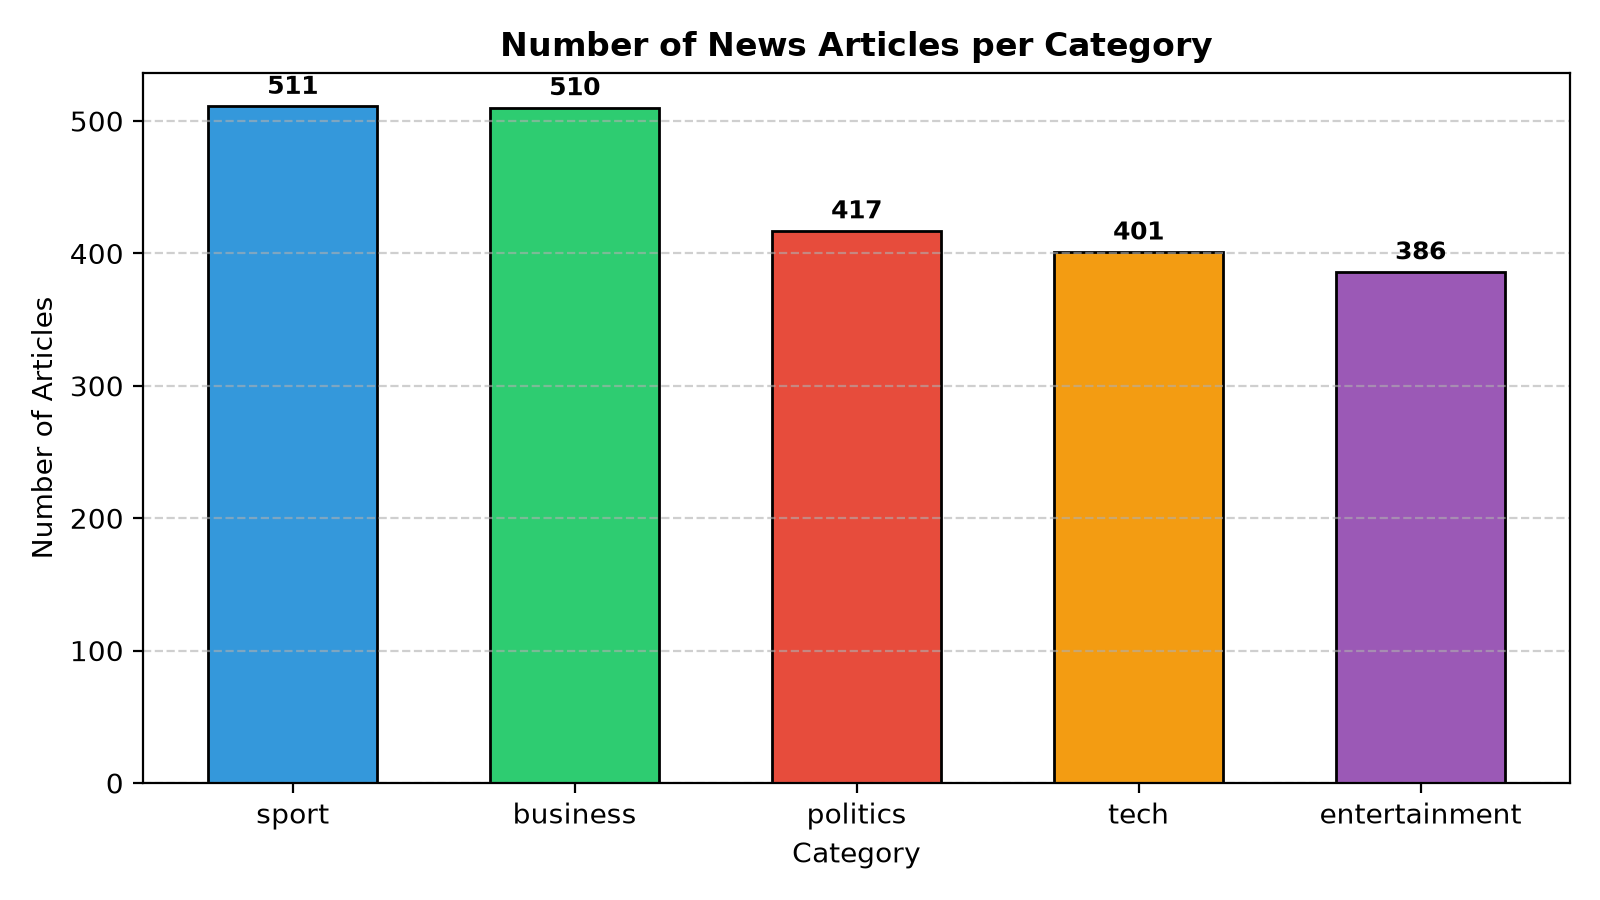

In [6]:
# Visual 1: Category distribution bar chart
plt.figure(figsize=(8, 4.5))
cat_counts = df['category'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
bars = plt.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='black', width=0.6)
plt.title('Number of News Articles per Category', fontsize=12, fontweight='bold')
plt.xlabel('Category', fontsize=10)
plt.ylabel('Number of Articles', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'{int(yval)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation of Chart 1:**
- The dataset contains 5 classes. Sport (511) and Business (510) have the highest counts, while Entertainment (386) has the lowest.
- The dataset is well-balanced (each category represents between 17% and 23% of total articles). There is no extreme class imbalance requiring synthetic oversampling techniques like SMOTE.

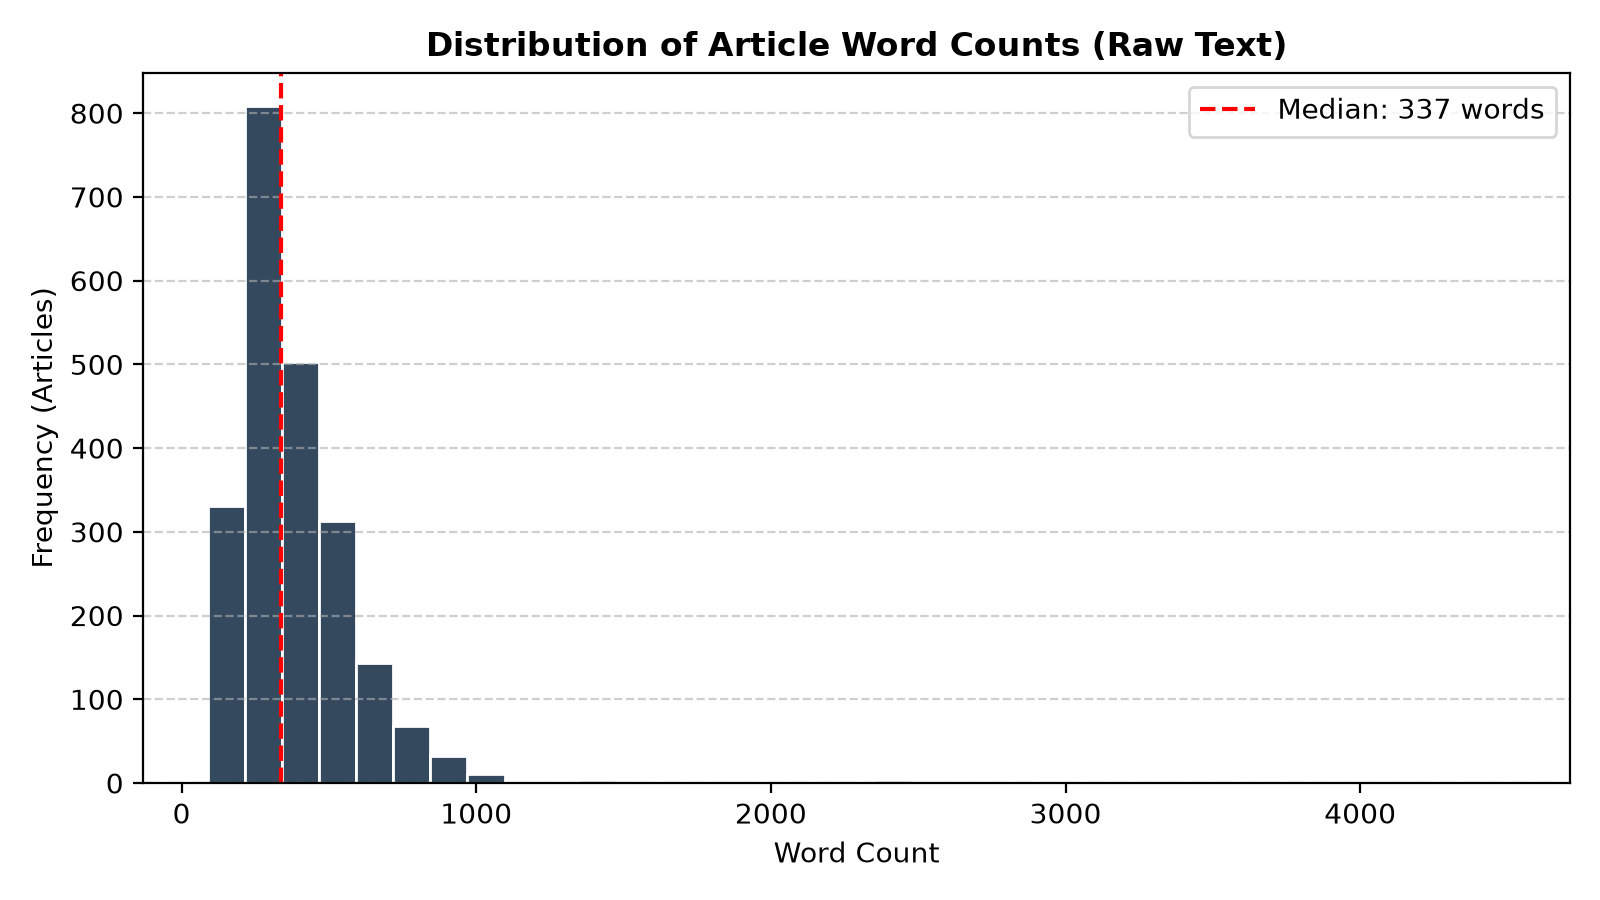

In [7]:
# Visual 2: Article length distribution
plt.figure(figsize=(8, 4.5))
plt.hist(df['raw_word_count'], bins=35, color='#34495e', edgecolor='white')
plt.title('Distribution of Article Word Counts (Raw Text)', fontsize=12, fontweight='bold')
plt.xlabel('Word Count', fontsize=10)
plt.ylabel('Frequency (Articles)', fontsize=10)
plt.axvline(df['raw_word_count'].median(), color='red', linestyle='dashed', linewidth=1.5, label=f'Median: {df["raw_word_count"].median():.0f} words')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretation of Chart 2:**
- Article lengths are right-skewed. Most news articles have between 200 and 500 words, with a median of 337 words.
- Some articles are unusually long (up to 4,492 words in politics). This confirms the need for TF-IDF normalization so article length does not artificially bias word frequency counts.

### 7. Hand-off to Member 2 (Lowercasing)

In [8]:
# Save inspected dataset for Member 2
df[['category', 'text']].to_csv('../results/outputs/step1_inspected_text.csv', index=False)
print("Output saved to: ../results/outputs/step1_inspected_text.csv")
print("Ready for Member 2 (IT25101913 - Lowercasing).")

Output saved to: ../results/outputs/step1_inspected_text.csv
Ready for Member 2 (IT25101913 - Lowercasing).
